<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/Student_MobileNetV3_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 · Student Candidate — MobileNetV3-Small (from scratch)

MobileNetV3-Small architecture trained from random (Kaiming) initialization.
~2.5M parameters. Same architecture as notebook 09, but no pretrained weights.

## Role in the 2×2 comparison

| | Scratch | Pretrained |
|---|---|---|
| **MobileNetV2** | notebook 06 | notebook 07 |
| **MobileNetV3** | **← this notebook** | notebook 09 |

**Two claims this notebook helps answer:**

1. *Architecture effect (scratch):* Does V3 beat V2 when both train from scratch?
   Compare this notebook against notebook 06 (V2 scratch).

2. *Initialization effect on V3:* Does pretraining improve MobileNetV3 on VWW?
   Compare this notebook against notebook 09 (same architecture, pretrained weights).

**Expected outcome:** This model underperforms notebook 09 (V3 pretrained),
confirming that ImageNet initialization provides meaningful benefit even for
a binary classification task on 7,000 images.


In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/thesis/utils/")


Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Standard imports ────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import (
    MobileNetV2_Scratch, MobileNetV2_Pretrained,
    MobileNetV3_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb, STUDENT_REGISTRY,
)
from utils.train import (
    setup_device, set_seed, evaluate,
    train_multi_seed, plot_history,
)

device = setup_device(seed=41)


Device: cuda


In [3]:
# ── Dataset setup ───────────────────────────────────────────────────
prepare_dataset()


1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests


PosixPath('/content/vww_work/extracted/vw_coco2014_96')

## Standardized hyperparameters

All four student models use **identical training conditions** to ensure the
comparison is controlled — only architecture and initialization vary.

| Parameter | Scratch models | Pretrained models |
|-----------|---------------|-------------------|
| Batch size | 64 | 64 |
| Optimizer | Adam | Adam |
| Weight decay | 1e-4 | 1e-4 |
| Label smoothing | 0.1 | 0.1 |
| Augmentation | standard | standard |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Patience | 10 | 10 |
| Seeds | [41, 52, 63] | [41, 52, 63] |
| Max epochs | 50 | 25 |
| LR | 1e-3 | 3e-4 (head) → 1e-4 (full) |


In [4]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [5]:
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")


Train: 7000 | Val: 1500 | Batch: 64


In [6]:
results, best = train_multi_seed(
    model_fn     = MobileNetV3_Scratch,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63],
    save_dir     = SAVE_DIR,
    name_prefix  = "mobilenetv3_scratch",
    pretrained   = False,
    # Standard scratch hyperparameters
    epochs          = 50,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 10,
)



Seed 41
Epoch   1/50 | LR 0.000999 | Train 58.90% | Val 50.00% ✅
Epoch   2/50 | LR 0.000996 | Train 63.51% | Val 50.00%
Epoch   3/50 | LR 0.000991 | Train 64.61% | Val 50.00%
Epoch   4/50 | LR 0.000984 | Train 65.89% | Val 50.07% ✅
Epoch   5/50 | LR 0.000976 | Train 67.40% | Val 50.40% ✅
Epoch   6/50 | LR 0.000965 | Train 68.66% | Val 65.33% ✅
Epoch   7/50 | LR 0.000952 | Train 69.81% | Val 68.07% ✅
Epoch   8/50 | LR 0.000938 | Train 70.74% | Val 69.20% ✅
Epoch   9/50 | LR 0.000922 | Train 71.67% | Val 71.67% ✅
Epoch  10/50 | LR 0.000905 | Train 71.63% | Val 70.53%
Epoch  11/50 | LR 0.000885 | Train 72.61% | Val 72.40% ✅
Epoch  12/50 | LR 0.000864 | Train 73.01% | Val 72.27%
Epoch  13/50 | LR 0.000842 | Train 73.57% | Val 73.47% ✅
Epoch  14/50 | LR 0.000819 | Train 74.60% | Val 72.27%
Epoch  15/50 | LR 0.000794 | Train 74.23% | Val 70.60%
Epoch  16/50 | LR 0.000768 | Train 74.81% | Val 73.67% ✅
Epoch  17/50 | LR 0.000741 | Train 75.10% | Val 74.53% ✅
Epoch  18/50 | LR 0.000713 | Train

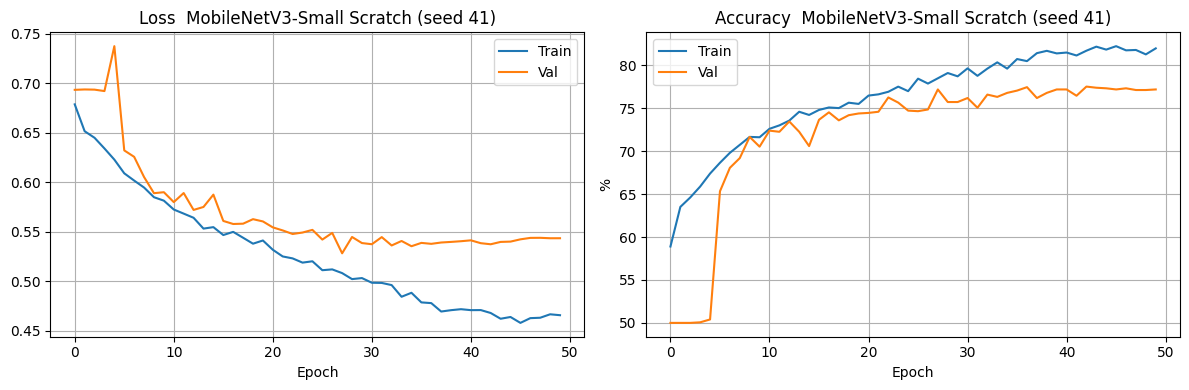

Best: 77.53% @ epoch 43  (12.3 min)

MobileNetV3-Small Scratch
  Mean ± Std : 77.09% ± 0.58%
  Best       : 77.53% @ epoch 43 (seed 41)
  Checkpoint : /content/drive/My Drive/Colab Notebooks/mobilenetv3_scratch_seed_41.pth


In [7]:
plot_history(best, title=f"MobileNetV3-Small Scratch (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nMobileNetV3-Small Scratch")
print(f"  Mean ± Std : {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
print(f"  Best       : {best['best_acc']*100:.2f}% @ epoch {best['best_epoch']} (seed {best['seed']})")
print(f"  Checkpoint : {best['save_path']}")


In [8]:
# ── Quick parameter/size summary ────────────────────────────────────
m = MobileNetV3_Scratch()
total, _ = count_params(m)
size = model_size_mb(m)
print(f"MobileNetV3-Small Scratch  |  Params: {total/1e6:.2f}M  |  Size: {size:.2f}MB")
print(f"Same parameter count as V3 Pretrained (nb 09) — only initialization differs.")


MobileNetV3-Small Scratch  |  Params: 1.52M  |  Size: 6.21MB
Same parameter count as V3 Pretrained (nb 09) — only initialization differs.
